---
title: "Structured linear layers: 1×1 conv & ActNorm"
short_title: "03 · 1×1 conv & ActNorm"
subtitle: "The LU-parameterised invertible 1×1 convolution and data-dependent ActNorm — cheap log-dets that make deep flows trainable"
description: >
  Rotations are orthogonal mixers with log-det 0. Glow added two structured
  linear layers that are *not* volume-preserving but still have O(d) log-dets:
  the invertible 1×1 convolution (a general linear channel mixer stored in LU
  form, log|det| = sum log|s|) and ActNorm (a data-dependent per-channel affine).
  This notebook builds both from gauss_flows, shows the LU trick keeps the map
  invertible under training, and shows ActNorm's data-dependent initialisation.
---

(sec-nb-rot-03)=
# 03 — Structured linear layers: 1×1 conv & ActNorm

Notebooks [00](00_rotation_zoo.ipynb)–[02](02_fixed_pca_warmstart.ipynb) covered
**orthogonal** mixers: rotations, which are volume-preserving ($\log|\det| = 0$).
But the "between-coordinate" toolkit has two more members, both introduced by
**Glow** {cite}`kingma2018glow`, that are *general* linear maps — not orthogonal,
so they carry a real log-det — yet keep that log-det **cheap** ($O(d)$ instead of
$O(d^3)$) by construction:

- The **invertible $1\times1$ convolution** — a learnable dense channel mixer
  $y = Wx$, stored in **LU** form so $\log|\det W| = \sum\log|s|$.
- **ActNorm** — a per-channel affine $y = (x-b)/s$ with a **data-dependent**
  initialisation that standardises activations and makes deep stacks trainable.

Together with coupling layers, these are the repeating unit of a Glow step
(ActNorm → $1\times1$ conv → coupling). Here we build the two linear pieces with
`gauss_flows`.

**What you will see**

- The $1\times1$ conv as a per-pixel channel mixer, with $\log|\det W| =
  \sum\log|s|$ verified against the dense determinant.
- Why **LU** matters: the map stays *exactly invertible* under training, where a
  raw matrix (notebook 02) would drift singular.
- **ActNorm**'s data-dependent init from a batch — output mean $\approx 0$,
  std $\approx 1$ per channel — and why that conditioning helps depth.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax

import gauss_flows as gf
from _style import style_ax

jax.config.update("jax_enable_x64", True)
rng = np.random.default_rng(0)

## 1. The invertible $1\times1$ convolution

A $1\times1$ convolution applies the **same** linear map $W$ to the channel
vector at every spatial location: $y_{ij} = W x_{ij}$, $W\in\mathbb{R}^{C\times
C}$. It is the learnable generalisation of the *fixed channel permutation* that
RealNVP used to shuffle coordinates between coupling layers — instead of a hard
permutation, a soft, trainable mixing. `gf.Invertible1x1Conv` operates on one
channel vector $(C,)$; we `vmap` it across the spatial grid.

log_det (analytic, = sum log|s|) = +0.5000
sum(log_diag_u)                  = +0.5000
log|det W| (dense, O(d^3))       = +0.5000
round-trip = 2.2e-16



on an 8x8 map: total log-det = 32.000 = 0.500 x 64 pixels


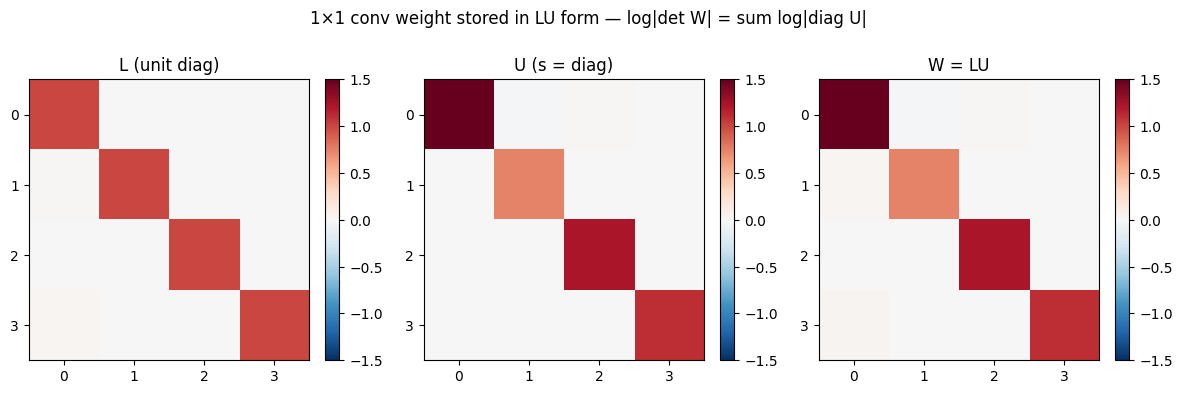

In [2]:
C = 4
conv = gf.Invertible1x1Conv(jr.key(0), n_channels=C)

# Make the log-det non-trivial by setting the U-diagonal (log s); near-identity
# at init otherwise. Its parameters are L (unit-diag), U (positive-diag = exp(log_diag_u)).
conv = eqx.tree_at(lambda m: m.log_diag_u, conv, jnp.array([0.5, -0.3, 0.2, 0.1]))

W = jax.vmap(conv.transform)(jnp.eye(C)).T          # effective matrix W (columns W e_j)
xch = jr.normal(jr.key(1), (C,))
z, ld = conv.transform_and_log_det(xch)
xi, _ = conv.inverse_and_log_det(z)

print(f"log_det (analytic, = sum log|s|) = {float(ld):+.4f}")
print(f"sum(log_diag_u)                  = {float(jnp.sum(jnp.array([0.5,-0.3,0.2,0.1]))):+.4f}")
print(f"log|det W| (dense, O(d^3))       = {float(jnp.linalg.slogdet(W)[1]):+.4f}")
print(f"round-trip = {float(jnp.abs(xch - xi).max()):.1e}")

# Apply across an 8x8 feature map: same W at every pixel, log-det adds up.
img = jr.normal(jr.key(2), (C, 8, 8))
flat = img.reshape(C, -1).T                          # (pixels, C)
z_pix = jax.vmap(conv.transform)(flat)
ld_pix = jax.vmap(lambda p: conv.transform_and_log_det(p)[1])(flat)
print(f"\non an 8x8 map: total log-det = {float(ld_pix.sum()):.3f} "
      f"= {float(ld):.3f} x {flat.shape[0]} pixels")

# Show the LU structure and the resulting W.
P, Lmat, Umat = jax.scipy.linalg.lu(np.asarray(W))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, Mx, name in zip(axes, [Lmat, Umat, W], ["L (unit diag)", "U (s = diag)", "W = LU"]):
    im = ax.imshow(np.asarray(Mx), cmap="RdBu_r", vmin=-1.5, vmax=1.5)
    ax.set(title=name, xticks=range(C), yticks=range(C))
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("1×1 conv weight stored in LU form — log|det W| = sum log|diag U|", y=1.04)
fig.tight_layout()

The analytic log-det matches the dense $\log|\det W|$ exactly, and round-trip is
machine-precision. Across the $8\times8$ map the per-pixel log-det simply
multiplies by the number of positions ($64$). Unlike a rotation, $W$ is a
*general* linear map, so its log-det is non-zero — but reading it off the
triangular factor's diagonal costs $O(d)$, not the $O(d^3)$ of a dense
determinant.

## 2. Why LU: invertible by construction, cheap log-det

Two problems with learning a raw weight $W$: (i) computing $\log|\det W|$ at every
step is $O(d^3)$, and (ii) nothing keeps $W$ invertible — gradient steps can drive
it singular, and [notebook 02 §2](02_fixed_pca_warmstart.ipynb) showed an
unconstrained matrix drifting off the manifold entirely. The **LU
parameterisation** $W = LU$ fixes both: $L$ is unit-lower-triangular, $U$ is
upper-triangular with $\mathrm{diag}(U) = \exp(\text{log\_diag\_u}) > 0$, so $W$ is
**always invertible** and $\log|\det W| = \sum_i \text{log\_diag\_u}_i$ is read
straight off. We confirm it survives training intact, on an arbitrary objective.

In [3]:
batch = jr.normal(jr.key(3), (2000, C)) * jnp.array([3.0, 0.5, 2.0, 1.0])

def loss_fn(layer):
    Y = jax.vmap(layer.transform)(batch)
    return jnp.mean((jnp.sum(Y ** 2, axis=1) - C) ** 2)   # arbitrary, just to move params

conv0 = gf.Invertible1x1Conv(jr.key(0), n_channels=C)
params, static = eqx.partition(conv0, eqx.is_inexact_array)
opt = optax.adam(1e-2)
state = opt.init(params)

@eqx.filter_jit
def step(params, state):
    loss, g = eqx.filter_value_and_grad(lambda p: loss_fn(eqx.combine(p, static)))(params)
    upd, state = opt.update(g, state)
    return eqx.apply_updates(params, upd), state, loss

for _ in range(300):
    params, state, _ = step(params, state)
trained = eqx.combine(params, static)

W_t = jax.vmap(trained.transform)(jnp.eye(C)).T
ld_t = float(trained.transform_and_log_det(batch[0])[1])
x = batch[0]; xi_t, _ = trained.inverse_and_log_det(trained.transform(x))
print("after 300 training steps:")
print(f"  analytic log_det = {ld_t:+.4f}   dense log|det W| = {float(jnp.linalg.slogdet(W_t)[1]):+.4f}  (match)")
print(f"  round-trip       = {float(jnp.abs(x - xi_t).max()):.1e}  (still exactly invertible)")
print(f"  det W            = {float(jnp.linalg.det(W_t)):+.4f}  (never crossed 0)")

after 300 training steps:
  analytic log_det = -2.2268   dense log|det W| = -2.2268  (match)
  round-trip       = 2.2e-16  (still exactly invertible)
  det W            = +0.1079  (never crossed 0)


The analytic and dense log-dets stay equal, the round-trip stays at machine
precision, and $\det W$ never approaches $0$: the LU form keeps the layer a
valid bijector for free, the structured counterpart to the orthogonal
parameterisations of notebook 01. That is the whole reason flows store linear
layers factored rather than dense.

## 3. ActNorm — data-dependent affine

**ActNorm** is the simplest structured layer: a per-channel affine
$y = (x - b)\,/\,s$ with learnable location $b$ and positive scale
$s = \mathrm{softplus}(\text{log\_scale}) + 10^{-5}$. Its log-det is
$-\sum_c \log s_c$ (times the number of spatial positions for an image). The
trick that gives it its name is the **data-dependent initialisation**: set $b$ and
$s$ from the *first* batch's per-channel mean and std, so the layer's output
starts standardised — zero mean, unit variance per channel. That conditioning is
what lets very deep stacks train without the activations exploding or collapsing.

`gauss_flows` exposes the parameters but not a `from_data` factory (unlike
`FixedRotation.from_data`), so we write the three-line init ourselves.

per-channel statistics of the output:
  default init : mean [ 7.05 -2.88  0.04  1.4 ]  std [4.3  0.71 2.89 1.46]
  data init    : mean [ 0.  0.  0. -0.]  std [1. 1. 1. 1.]


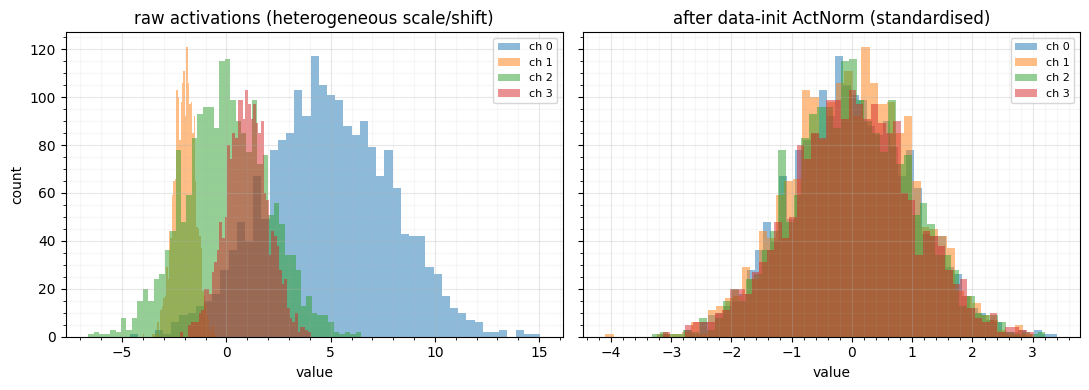

In [4]:
def actnorm_from_data(batch):
    """Data-dependent ActNorm init: loc = per-channel mean, scale = per-channel std."""
    mu = batch.mean(axis=0)
    sd = batch.std(axis=0)
    inv_softplus = lambda y: jnp.log(jnp.expm1(y))            # softplus^{-1}
    log_scale = inv_softplus(jnp.clip(sd - 1e-5, 1e-6))
    layer = gf.ActNorm(shape=(batch.shape[1],))
    return eqx.tree_at(lambda m: (m.loc, m.log_scale), layer, (mu, log_scale))

# A batch with very different per-channel mean/scale.
raw = jr.normal(jr.key(4), (2000, C)) * jnp.array([3.0, 0.5, 2.0, 1.0]) + jnp.array([5.0, -2.0, 0.0, 1.0])

default_out = jax.vmap(gf.ActNorm(shape=(C,)).transform)(raw)     # log_scale = 0 -> scale ~ 0.69
datainit = actnorm_from_data(raw)
datainit_out = jax.vmap(datainit.transform)(raw)

print("per-channel statistics of the output:")
print(f"  default init : mean {np.round(np.asarray(default_out.mean(0)), 2)}  std {np.round(np.asarray(default_out.std(0)), 2)}")
print(f"  data init    : mean {np.round(np.asarray(datainit_out.mean(0)), 2)}  std {np.round(np.asarray(datainit_out.std(0)), 2)}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
for c in range(C):
    axes[0].hist(np.asarray(raw[:, c]), bins=50, alpha=0.5, label=f"ch {c}")
    axes[1].hist(np.asarray(datainit_out[:, c]), bins=50, alpha=0.5, label=f"ch {c}")
axes[0].set(title="raw activations (heterogeneous scale/shift)", xlabel="value", ylabel="count")
axes[1].set(title="after data-init ActNorm (standardised)", xlabel="value")
for ax in axes:
    ax.legend(fontsize=8); style_ax(ax)
fig.tight_layout()

The default ActNorm (with `log_scale = 0`) just divides every channel by
$\mathrm{softplus}(0)\approx0.69$ — it ignores the data's wildly different
per-channel scales and offsets. The data-initialised ActNorm pins every channel
to mean $\approx 0$, std $\approx 1$, so the next layer sees well-conditioned
inputs. Stacked through a deep flow, this is the difference between a network that
trains and one whose log-likelihood diverges in the first few steps.

## 4. How they fit together

A Glow "step" is exactly these pieces in sequence: **ActNorm** preconditions the
activations, the **$1\times1$ conv** mixes channels (replacing RealNVP's fixed
permutation), and a **coupling** layer (Part 5) does the expressive nonlinear
work. All three have triangular or diagonal Jacobians, so their log-dets are
$O(d)$ and simply add (Part 0
[composition](../00_foundations/01_composition_logdet.ipynb)). The orthogonal
mixers of notebooks 00–02 slot into the same position as the $1\times1$ conv —
the choice is *orthogonal* (log-det 0, volume-preserving) versus *general linear*
(log-det $\sum\log|s|$, can rescale).

## Recap

| layer | map | log-det | kept valid by | API |
|---|---|---|---|---|
| rotation (nb 00–02) | $Qx$, orthogonal | $0$ | orthogonal parameterisation | `gf.HouseholderRotation`, … |
| $1\times1$ conv | $Wx$, general linear | $\sum\log|s|$ | LU factorisation | `gf.Invertible1x1Conv` |
| ActNorm | $(x-b)/s$, diagonal affine | $-\sum\log s$ | positive scale, data init | `gf.ActNorm` / `ActNorm1D` |

Rotations re-frame without rescaling; the $1\times1$ conv adds learnable
rescaling with a cheap log-det; ActNorm adds the data-dependent conditioning that
makes depth trainable. That completes the **between-coordinate** toolkit.

**Next up — Part 3.** With marginal transforms (Part 1) and orthogonal/linear
mixers (Part 2) in hand, we can assemble the classic algorithm that alternates
them to convergence: **Rotation-Based Iterative Gaussianization (RBIG)** — the
non-parametric loop `marginal → rotate → marginal → rotate …` that drives a
distribution to $\mathcal{N}(0,I)$, with negentropy as its stopping signal.